# French Corporate Network — Annuaire des Entreprises

This notebook builds a **corporate officer network** from the French government's open data API: the [Annuaire des Entreprises](https://annuaire-entreprises.data.gouv.fr/) (data.gouv.fr).

For a set of major French companies, we fetch their registered officers (*dirigeants*) and auditors, then load the resulting bipartite graph into TuringDB using `LOAD JSONL`.

## Graph model
- **`Company` nodes** — identified by SIREN number, with sector and category attributes
- **`Person` nodes** — individuals holding a mandate, with birth year
- **`IS_OFFICER_OF` edges** — `(Person)-[:IS_OFFICER_OF {qualite}]->(Company)`, with the role (`qualite`) as a property
- **`IS_AUDITOR_OF` edges** — `(AuditFirm)-[:IS_AUDITOR_OF]->(Company)`, for statutory auditors

## Questions we can answer
- Which companies have the most officers?
- Who sits on the most boards (interlocking directorates)?
- What is the approximate age of company officers?
- Which CEOs (*Directeur Général*) are shared across multiple companies?

**Data source**: `recherche-entreprises.api.gouv.fr` — free, no authentication required, official data.gouv.fr infrastructure.

## 1. Setup

In [1]:
import os
import time
import json
import requests
import pandas as pd
import networkx as nx
from IPython.display import display
from dotenv import load_dotenv
import numpy as np
from tqdm.auto import tqdm

import turingdb
from turingdb_examples.graph import networkx_to_jsonl
from turingdb_examples.llm import natural_language_to_cypher

load_dotenv()

True

In [2]:
graph_name = "french_corporate_network"
example_name = "french_corporate_network"
path_data = f"{os.getcwd()}/data/{example_name}"
os.makedirs(path_data, exist_ok=True)

API_URL = "https://recherche-entreprises.api.gouv.fr/search"

COMPANIES = {
    # --- CAC 40 (French-registered) ---
    # Companies incorporated outside France have no SIREN:
    #   Stellantis (NL), STMicroelectronics (NL), Unibail-Rodamco-Westfield (NL),
    #   ArcelorMittal (LU), Eurofins Scientific (LU)
    "Accor":                "602036444",
    "Air Liquide":          "552096281",
    "Airbus":               "383474814",
    "Alstom":               "389058447",
    "AXA":                  "572093920",
    "BNP Paribas":          "662042449",
    "Bouygues":             "572015246",
    "Capgemini":            "330703844",
    "Carrefour":            "652014051",
    "Crédit Agricole":      "784608416",
    "Danone":               "552032534",
    "Dassault Systèmes":    "322306440",
    "Engie":                "542107651",
    "EssilorLuxottica":     "712049618",
    "Hermès":               "572076396",
    "Kering":               "552075020",
    "Legrand":              "389290586",
    "L'Oréal":              "632012100",
    "LVMH":                 "775670417",
    "Michelin":             "855200887",
    "Orange":               "380129866",
    "Pernod Ricard":        "582041943",
    "Publicis":             "542080601",
    "Renault":              "780129987",
    "Safran":               "562082909",
    "Saint-Gobain":         "542039532",
    "Sanofi":               "395030844",
    "Schneider Electric":   "542048574",
    "Société Générale":     "552120222",
    "Teleperformance":      "301292702",
    "Thales":               "552059024",
    "TotalEnergies":        "542051180",
    "Veolia":               "403210032",
    "Vinci":                "552037806",
    "Vivendi":              "343134763",  # owns Canal+, CNews, C8
    "Worldline":            "378901946",

    # --- Media & Telecoms ---
    "TF1":                  "326300159",  # 43% owned by Bouygues
    "M6 (Metropole TV)":    "339012452",
    "Lagardère":            "320366446",  # Europe 1, Paris Match, JDD
    "Groupe Figaro":        "401328919",  # Le Figaro — 65% owned by Dassault Aviation
    "Les Échos":            "582071437",  # owned by LVMH
    "Société Editrice du Monde": "433891850",  # Le Monde — Xavier Niel, Pigasse
    "NRJ Group":            "332036128",
    "Altice France":        "794661470",  # SFR, BFMTV, RMC, L'Express
    "Mediawan":             "815286398",  # Xavier Niel
    "Prisma Media":         "318826187",  # Femme Actuelle, Capital, Geo
    "Iliad (Free)":         "342376332",  # Xavier Niel — also owns Le Monde stake
    "Dassault Aviation":    "712042456",  # owns Groupe Figaro (Le Figaro)
    "Ubisoft":              "335186094",

    # --- Other major French companies ---
    "EDF":                  "552081317",
    "ADP (Aéroports de Paris)": "552016628",
    "SNCF":                 "552049447",
    "La Poste":             "356000000",
    "BPCE":                 "493455042",
    "Air France-KLM":       "552043002",
    "Amundi":               "314222902",
    "Arkema":               "445074685",
    "Bureau Veritas":       "775690621",
    "CNP Assurances":       "341737062",
    "Eiffage":              "709802094",
    "Eurazeo":              "692030992",
    "Imerys":               "562008151",
    "Nexans":               "393525852",
    "Nexity":               "444346795",
    "OPmobility":           "955512611",
    "SEB":                  "300349636",
    "Sodexo":               "301940219",
    "Sopra Steria":         "326820065",
    "Valeo":                "552030967",
}

print(f"Will fetch data for {len(COMPANIES)} companies")

Will fetch data for 69 companies


## 2. Fetch data from the Annuaire des Entreprises API

In [3]:
%%time

raw_companies = []

for name, siren in tqdm(COMPANIES.items()):
    resp = requests.get(API_URL, params={"q": siren, "per_page": 1})
    resp.raise_for_status()
    results = resp.json().get("results", [])
    if not results:
        print(f"  ⚠ Not found: {name} ({siren})")
        continue
    company = results[0]
    raw_companies.append(company)
    print(f"  ✓ {company['nom_complet']} — {len(company.get('dirigeants', []))} dirigeants")
    time.sleep(0.15)

print(f"\nFetched {len(raw_companies)} companies")

  0%|          | 0/69 [00:00<?, ?it/s]

  ✓ ACCOR (ACCOR) — 15 dirigeants
  ✓ L'AIR LIQUIDE SOCIETE ANONYME POUR L'ETUDE ET L'EXPLOITATION DES PROCEDES GEORGES CLAUDE — 16 dirigeants
  ✓ AIRBUS — 6 dirigeants
  ✓ ALSTOM — 14 dirigeants
  ✓ AXA — 17 dirigeants
  ✓ BNP PARIBAS (HELLO BANK!) — 19 dirigeants
  ✓ BOUYGUES — 19 dirigeants
  ✓ CAPGEMINI — 17 dirigeants
  ✓ CARREFOUR — 16 dirigeants
  ✓ CREDIT AGRICOLE SA — 26 dirigeants
  ✓ DANONE — 13 dirigeants
  ✓ DASSAULT SYSTEMES — 16 dirigeants
  ✓ ENGIE — 16 dirigeants
  ✓ ESSILORLUXOTTICA — 16 dirigeants
  ✓ HERMES INTERNATIONAL — 19 dirigeants
  ✓ KERING — 18 dirigeants
  ✓ LEGRAND SNC — 4 dirigeants
  ✓ L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSIONNEL PARIS ; ESSIE PROFESSIONNEL ; BAXTER OF CALIFORNIA ; BIOL) — 20 dirigeants
  ✓ LVMH MOET HENNESSY LOUIS VUITTON — 18 dirigeants
  ✓ COMPAGNIE GENERALE DES ETABLISSEMENTS MICHELIN (CGEM) — 14 dirigeants
  ✓ ORANGE — 21 dirigeants
  ✓ PERNOD RICARD — 17 dirigeants
  ✓ PUBLICIS GROUPE S.A. — 16 dirigeants
  ✓ RENAULT SAS — 1

## 3. Explore the data

In [4]:
# Build a summary DataFrame
rows = []
for c in raw_companies:
    dirigeants = c.get("dirigeants", [])
    rows.append({
        "siren": c["siren"],
        "nom": c["nom_complet"],
        "secteur": c.get("activite_principale", ""),
        "categorie": c.get("categorie_entreprise", ""),
        "nature_juridique": c.get("nature_juridique", ""),
        "date_creation": c.get("date_creation", ""),
        "nb_personnes_physiques": sum(1 for d in dirigeants if d["type_dirigeant"] == "personne physique"),
        "nb_personnes_morales": sum(1 for d in dirigeants if d["type_dirigeant"] == "personne morale"),
    })
    #print(c)
    #print()

df_companies = pd.DataFrame(rows)
print(f"Companies: {len(df_companies)}")
print(f"Total officers (persons): {df_companies['nb_personnes_physiques'].sum()}")
print(f"Total auditors (firms): {df_companies['nb_personnes_morales'].sum()}")
display(df_companies)

Companies: 69
Total officers (persons): 929
Total auditors (firms): 193


,siren,nom,secteur,categorie,nature_juridique,date_creation,nb_personnes_physiques,nb_personnes_morales
0,602036444,ACCOR (ACCOR),70.10Z,GE,5599,1983-07-04,13,2
1,552096281,L'AIR LIQUIDE SOCIETE ANONYME POUR L'ETUDE ET ...,78.30Z,GE,5599,1955-01-01,14,2
2,383474814,AIRBUS,30.30Z,GE,5710,1991-10-18,4,2
3,389058447,ALSTOM,70.10Z,GE,5599,1992-10-29,10,4
4,572093920,AXA,64.30Z,GE,5599,1957-01-01,14,3
...,...,...,...,...,...,...,...,...
64,955512611,OPMOBILITY SE,70.10Z,ETI,5800,1955-01-01,13,2
65,300349636,SEB SA,64.20Z,GE,5599,1974-01-01,11,6
66,301940219,SODEXO,56.29B,GE,5599,1975-01-01,12,3
67,326820065,SOPRA STERIA GROUP,62.02A,GE,5599,1968-01-01,18,3


In [5]:
# Most common officer roles across all companies
all_roles = []
for c in raw_companies:
    for d in c.get("dirigeants", []):
        if d["type_dirigeant"] == "personne physique":
            all_roles.append(d.get("qualite", "Unknown"))

df_roles = pd.Series(all_roles).value_counts().reset_index()
df_roles.columns = ["role", "count"]
print("Top officer roles:")
display(df_roles.head(15))

Top officer roles:


,role,count
0,Administrateur,562
1,Autre,85
2,Membre du conseil de surveillance,84
3,Administrateurs représentant les salariés,54
4,Président du conseil d'administration,29
5,Directeur Général,29
6,Directeur général délégué,20
7,Président du conseil d'administration et direc...,15
8,Membre du directoire,12
9,Président du conseil de surveillance,7


## 4. Build the NetworkX graph

In [6]:
G = nx.DiGraph()

for c in raw_companies:
    siren = c["siren"]

    # Add company node
    G.add_node(
        siren,
        type="Company",
        displayName=c["nom_complet"],
        secteur=c.get("activite_principale") or "",
        categorie=c.get("categorie_entreprise") or "",
        date_creation=c.get("date_creation") or "",
    )

    for d in c.get("dirigeants", []):
        qualite = d.get("qualite", "")

        if d["type_dirigeant"] == "personne physique":
            nom = d.get("nom", "")
            prenoms = d.get("prenoms", "")
            annee = d.get("annee_de_naissance")
            person_id = f"{nom}_{prenoms}_{annee or ''}"

            G.add_node(
                person_id,
                type="Person",
                displayName=f"{prenoms} {nom}".strip(),
                nom=nom,
                prenoms=prenoms,
                annee_de_naissance=int(annee) if annee else 0,
            )
            # Person IS_OFFICER_OF Company
            G.add_edge(person_id, siren, type="IS_OFFICER_OF", qualite=qualite)

        elif d["type_dirigeant"] == "personne morale" and d.get("siren"):
            auditor_siren = d["siren"]
            G.add_node(
                auditor_siren,
                type="Company",
                displayName=d.get("denomination", auditor_siren),
                secteur="",
                categorie="",
                date_creation="",
            )
            # Auditor firm IS_AUDITOR_OF Company
            G.add_edge(auditor_siren, siren, type="IS_AUDITOR_OF", qualite=qualite)

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"  Company nodes: {sum(1 for _, d in G.nodes(data=True) if d.get('type') == 'Company')}")
print(f"  Person nodes:  {sum(1 for _, d in G.nodes(data=True) if d.get('type') == 'Person')}")

Graph: 994 nodes, 1,115 edges
  Company nodes: 116
  Person nodes:  878


## 5. Load into TuringDB

In [7]:
client = turingdb.TuringDB()
print("TuringDB client connected")

TuringDB client connected


In [8]:
%%time

print("Writing graph to JSONL...")
jsonl_filename = networkx_to_jsonl(G, graph_name, node_type_key="type")

print(f"\nLoading JSONL into TuringDB as graph '{graph_name}' ...")
client.query(f"LOAD JSONL '{jsonl_filename}' AS {graph_name}")
client.set_graph(graph_name)
print(f"\n✓ Graph '{graph_name}' ready")

Writing graph to JSONL...
JSONL file written to: /home/ubuntu/.turing/data/french_corporate_network.jsonl
Graph: 994 nodes, 1,115 edges

Loading JSONL into TuringDB as graph 'french_corporate_network' ...

✓ Graph 'french_corporate_network' ready
CPU times: user 10.5 ms, sys: 16 μs, total: 10.5 ms
Wall time: 90.8 ms


## 6. Schema inspection

In [9]:
print("Node labels:")
display(client.query("CALL db.labels()"))

print("Edge types:")
display(client.query("CALL db.edgeTypes()"))

print("Property types:")
display(client.query("CALL db.propertyTypes()"))

Node labels:


,id,label
0,0,Company
1,1,Person


Edge types:


,id,edgeType
0,0,CONNECTED


Property types:


,id,propertyType,valueType
0,0,categorie,String
1,1,date_creation,String
2,2,displayName,String
3,3,id,String
4,4,secteur,String
5,5,type,String
6,6,annee_de_naissance,Int64
7,7,nom,String
8,8,prenoms,String
9,9,qualite,String


## 7. Graph queries

Since all nodes carry a `type` property, we filter semantically using `WHERE n.type = '...'` rather than label syntax.

In [10]:
# Count nodes by type
print("Company nodes:")
display(client.query("""
    MATCH (n) WHERE n.type = 'Company'
    RETURN count(n)
"""))

print("Person nodes:")
display(client.query("""
    MATCH (n) WHERE n.type = 'Person'
    RETURN count(n)
"""))

print("IS_OFFICER_OF edges:")
display(client.query("""
    MATCH ()-[r]->() WHERE r.type = 'IS_OFFICER_OF'
    RETURN count(r)
"""))

print("IS_AUDITOR_OF edges:")
display(client.query("""
    MATCH ()-[r]->() WHERE r.type = 'IS_AUDITOR_OF'
    RETURN count(r)
"""))

Company nodes:


,count(n)
0,116


Person nodes:


,count(n)
0,878


IS_OFFICER_OF edges:


,count(r)
0,929


IS_AUDITOR_OF edges:


,count(r)
0,186


In [11]:
# Sample officer relationships
print("Sample officer relationships:")
display(client.query("""
    MATCH (p)-[r]->(c)
    WHERE p.type = 'Person' AND c.type = 'Company' AND r.type = 'IS_OFFICER_OF'
    RETURN p.displayName, r.qualite, c.displayName
    LIMIT 15
"""))

Sample officer relationships:


,p.displayName,r.qualite,c.displayName
0,BRIGITTE JONON (DE SIO),Autre,LA POSTE
1,GILLES DENOYEL,Administrateur,ELECTRICITE DE FRANCE (EDF)
2,ANNE-MARIE DESCÔTES,Administrateur,ELECTRICITE DE FRANCE (EDF)
3,BRUNO EVEN,Administrateur,ELECTRICITE DE FRANCE (EDF)
4,AURELIE FRIONNET,Administrateurs représentant les salariés,ELECTRICITE DE FRANCE (EDF)
5,FABRICE GUYON,Administrateurs représentant les salariés,ELECTRICITE DE FRANCE (EDF)
6,GERALD LACOSTE,Administrateurs représentant les salariés,ELECTRICITE DE FRANCE (EDF)
7,STEPHANE CHEVET-DEHAIL,Autre,LA POSTE
8,VIRGINIE DE MOLLERAT DU JEU (CHAPRON),Administrateur,LA POSTE
9,SANDRINE LHENRY,Administrateurs représentant les salariés,ELECTRICITE DE FRANCE (EDF)


In [12]:
# Filter by role: Directeurs Généraux
print("Directeurs Généraux across all companies:")
display(client.query("""
    MATCH (p)-[r]->(c)
    WHERE p.type = 'Person' AND c.type = 'Company'
    AND r.qualite = 'Directeur Général'
    RETURN p.displayName, c.displayName
    LIMIT 30
"""))

Directeurs Généraux across all companies:


,p.displayName,c.displayName
0,PIERRE-ANTOINE VACHERON,WORLDLINE
1,MARC FEUILLEE,GROUPE FIGARO (GROUPE FIGARO CCM BENCHMARK)
2,JULIEN HUBERT,NEXANS
3,FELICIE CAROLINE BURELLE,OPMOBILITY SE
4,WILLIAM KADOUCH-CHASSAING (KADOUCH),EURAZEO
5,ALESSANDRO DAZZA,IMERYS
6,RAJESH KRISHNAMURTHY,SOPRA STERIA GROUP
7,STANISLAS MARIE ALAIN BOUBEE DE GRAMONT,SEB SA
8,HINDA GHARBI,BUREAU VERITAS (BUREAU VERITAS)
9,MARIE-AUDE THEPAUT,CNP ASSURANCES


In [13]:
# Filter by role: Présidents du conseil d'administration
print("Présidents du conseil d'administration:")
display(client.query("""
    MATCH (p)-[r]->(c)
    WHERE p.type = 'Person' AND c.type = 'Company'
    AND r.qualite = "Président du conseil d'administration"
    RETURN p.displayName, c.displayName
    LIMIT 30
"""))

Présidents du conseil d'administration:


,p.displayName,c.displayName
0,WILFRIED VERSTRAETE,WORLDLINE
1,YVES MARIE REMI GUILLEMOT,UBISOFT ENTERTAINMENT
2,JEAN MOUTON,NEXANS
3,LAURENT BURELLE,OPMOBILITY SE
4,THIERRY DELAUNOY DE LA TOUR D'ARTAISE,SEB SA
5,OLIVIER ERIC GAVALDA,AMUNDI
6,GILLES SCHNEPP,DANONE
7,BERNARD JOSEPH MARIE CHARLES,DASSAULT SYSTEMES
8,JEAN PIERRE LUC CLAMADIEU,ENGIE
9,ERIC VIAL,CREDIT AGRICOLE SA


In [14]:
# Persons with mandates in multiple companies (interlocking directorates)
print("Persons with mandates in multiple companies (interlocking directorates):")
df_officers = client.query("""
    MATCH (p)-[r]->(c)
    WHERE p.type = 'Person' AND c.type = 'Company' AND r.type = 'IS_OFFICER_OF'
    RETURN p.displayName, c.displayName, r.qualite
    LIMIT 1000
""")

# Find persons appearing in more than one company
mandates_per_person = df_officers.groupby("p.displayName")["c.displayName"].count().reset_index()
mandates_per_person.columns = ["person", "nb_mandates"]
interlocking = mandates_per_person[mandates_per_person["nb_mandates"] > 1].sort_values("nb_mandates", ascending=False)

print(f"Found {len(interlocking)} persons with mandates in multiple companies:")
display(interlocking)

Persons with mandates in multiple companies (interlocking directorates):
Found 47 persons with mandates in multiple companies:


,person,nb_mandates
169,CELINE FORNARO,4
172,CHARLES EDELSTENNE,3
26,ALEXIS ZAJDENWEBER,3
65,ANNETTE MESSEMER,2
67,ANNETTE WINKLER,2
7,AIMAN EZZAT,2
20,ALEXANDRE BOMPARD,2
82,ARNAUD ROY DE PUYFONTAINE,2
68,ANTOINE ARNAULT,2
111,BENOIT DE RUFFRAY,2


### Board members (Administrateurs) with multiple mandates

Beyond CEOs and board chairs, **Administrateurs** (non-executive board members) frequently hold seats across several major companies. This cross-pollination of boards is a key feature of French corporate governance.

In [15]:
# Full mandate detail for all interlocking directors
interlocking_names = set(interlocking["person"])
df_multi_detail = df_officers[df_officers["p.displayName"].isin(interlocking_names)].copy()
df_multi_detail.columns = ["person", "company", "role"]
df_multi_detail = df_multi_detail.sort_values(["person", "role"])

print("All mandates held by multi-company officers:")
display(df_multi_detail)

All mandates held by multi-company officers:


,person,company,role
595,AIMAN EZZAT,L'AIR LIQUIDE SOCIETE ANONYME POUR L'ETUDE ET ...,Administrateur
596,AIMAN EZZAT,CAPGEMINI,Directeur Général
628,ALEXANDRE BOMPARD,ORANGE,Administrateur
627,ALEXANDRE BOMPARD,CARREFOUR,Président du conseil d'administration et direc...
919,ALEXIS ZAJDENWEBER,RENAULT SAS,Autre
...,...,...,...
488,VÉRONIQUE WEILL (LEBEY),CNP ASSURANCES,Président du conseil d'administration
598,XAVIER HUILLARD,L'AIR LIQUIDE SOCIETE ANONYME POUR L'ETUDE ET ...,Administrateur
599,XAVIER HUILLARD,VINCI,Président du conseil d'administration
486,XIAOYING DUAN,SANOFI,Administrateur


In [16]:
# Multi-mandate people in non-executive roles (exclude top leadership)
executive_roles = {
    "Directeur Général",
    "Directeur général délégué",
    "Président du conseil d'administration",
    "Président Directeur Général",
    "Président du conseil de surveillance",
    "Président de SAS",
    "Gérant",
}

df_non_exec = df_officers[~df_officers["r.qualite"].isin(executive_roles)]
non_exec_counts = df_non_exec.groupby("p.displayName")["c.displayName"].count().reset_index()
non_exec_counts.columns = ["person", "nb_mandates"]
non_exec_multi = non_exec_counts[non_exec_counts["nb_mandates"] > 1].sort_values("nb_mandates", ascending=False)

print(f"Non-executive officers with mandates in multiple companies: {len(non_exec_multi)}")
display(non_exec_multi)

# Show their full mandate detail
df_non_exec_detail = df_non_exec[df_non_exec["p.displayName"].isin(non_exec_multi["person"])].copy()
df_non_exec_detail.columns = ["person", "company", "role"]
df_non_exec_detail = df_non_exec_detail.sort_values(["person", "role"])
print("\nMandate detail:")
display(df_non_exec_detail)

Non-executive officers with mandates in multiple companies: 34


,person,nb_mandates
157,CELINE FORNARO,4
25,ALEXIS ZAJDENWEBER,3
160,CHARLES EDELSTENNE,3
19,ALEXANDRE BOMPARD,2
67,ANTOINE ARNAULT,2
64,ANNETTE MESSEMER,2
78,ARNAUD ROY DE PUYFONTAINE,2
101,BENOIT BAZIN,2
103,BENOIT DE RUFFRAY,2
66,ANNETTE WINKLER,2



Mandate detail:


,person,company,role
628,ALEXANDRE BOMPARD,ORANGE,Administrateur
627,ALEXANDRE BOMPARD,CARREFOUR,Président du conseil d'administration et direc...
919,ALEXIS ZAJDENWEBER,RENAULT SAS,Autre
920,ALEXIS ZAJDENWEBER,THALES,Autre
921,ALEXIS ZAJDENWEBER,ELECTRICITE DE FRANCE (EDF),Autre
...,...,...,...
113,THIERRY DASSAULT,GROUPE FIGARO (GROUPE FIGARO CCM BENCHMARK),Autre
853,THIERRY LE HENAFF,COMPAGNIE GENERALE DES ETABLISSEMENTS MICHELIN...,Membre du conseil de surveillance
854,THIERRY LE HENAFF,ARKEMA,Président du conseil d'administration et direc...
486,XIAOYING DUAN,SANOFI,Administrateur


### Interlocking directorates — network visualization

The graph below shows **all officers who hold mandates in at least two companies**. Person nodes (orange) are sized by their number of mandates; company nodes (blue) are shown as boxes. Arrows represent the `IS_OFFICER_OF` relationship, labeled with the officer's role.

In [17]:
from pyvis.network import Network

# Map person displayName → node_id in G (person node IDs are composite strings)
interlocking_names = set(interlocking["person"])
name_to_nodeid = {
    attrs["displayName"]: node_id
    for node_id, attrs in G.nodes(data=True)
    if attrs.get("type") == "Person" and attrs.get("displayName") in interlocking_names
}

# Build subgraph: interlocking people and the companies they connect
G_inter = nx.DiGraph()
for person_name, person_id in name_to_nodeid.items():
    G_inter.add_node(person_id, **G.nodes[person_id])
    for _, company_id, edge_attrs in G.out_edges(person_id, data=True):
        if edge_attrs.get("type") == "IS_OFFICER_OF":
            G_inter.add_node(company_id, **G.nodes[company_id])
            G_inter.add_edge(person_id, company_id, **edge_attrs)

print(f"Interlocking network: {G_inter.number_of_nodes()} nodes, {G_inter.number_of_edges()} edges")

# Mandate count per person (for node sizing)
mandate_count = {pid: G_inter.out_degree(pid) for pid in name_to_nodeid.values()}

net_inter = Network(height="700px", width="100%", directed=True, notebook=True, cdn_resources="in_line")

for node_id, attrs in G_inter.nodes(data=True):
    label = attrs.get("displayName", str(node_id))
    if attrs.get("type") == "Company":
        net_inter.add_node(str(node_id), label=label, color="#4A90D9", size=20,
                           title=f"Company: {label}", shape="box")
    else:
        nb = mandate_count.get(node_id, 1)
        net_inter.add_node(str(node_id), label=label, color="#E07B39",
                           size=10 + nb * 8,
                           title=f"{label} — {nb} mandates")

for src, tgt, attrs in G_inter.edges(data=True):
    net_inter.add_edge(str(src), str(tgt), title=attrs.get("qualite", ""), color="#aaaaaa")

inter_path = "interlocking_network.html"  # f"{path_data}/interlocking_network.html"
net_inter.save_graph(inter_path)
print(f"Visualization saved to {inter_path}")
net_inter.show(inter_path)

Interlocking network: 92 nodes, 98 edges
Visualization saved to interlocking_network.html
interlocking_network.html


## 8. Understanding "Autre" roles — corporate representatives

In the Annuaire des Entreprises data (sourced from INPI), **"Autre"** is a catch-all category for roles that don't map to a standard legal mandate type. In practice it covers:

- **Représentant permanent** — when a legal entity (holding company, investment fund) holds a board seat and designates an individual as its permanent representative. The individual isn't personally a board member; they formally represent the corporate shareholder. This is very common in French corporate groups and explains why the same person appears across multiple companies (they're the designated face of a major shareholder across its portfolio).
- **Censeur** (observer) — a non-voting board observer with no formal legal mandate.
- **Custom SAS governance roles** — in a *Société par Actions Simplifiée*, statutes define governance freely, so titles like *Secrétaire Général* or *Directeur Adjoint* get registered as "Autre" since they have no standard INPI code.
- **Délégations de pouvoirs** — people with a specific registered signing authority who aren't officers in the strict legal sense.

When the same person appears as "Autre" at several companies, the **représentant permanent** scenario is most likely: they work for a financial holding that has stakes in multiple companies and they formally represent that entity at each board.

We can partially verify this by cross-referencing with `personne morale` entries in the raw API data — corporate entities that also hold mandates at the same companies.

In [18]:
# People with "Autre" role at multiple companies
df_autre = df_officers[df_officers["r.qualite"] == "Autre"].copy()
df_autre.columns = ["person", "company", "role"]

autre_counts = df_autre.groupby("person")["company"].count().reset_index()
autre_counts.columns = ["person", "nb_companies"]
autre_multi = autre_counts[autre_counts["nb_companies"] > 1].sort_values("nb_companies", ascending=False)

print(f"People with 'Autre' role at 2+ companies: {len(autre_multi)}")
display(autre_multi)

print("\nFull mandate detail:")
display(df_autre[df_autre["person"].isin(autre_multi["person"])].sort_values("person"))

People with 'Autre' role at 2+ companies: 2


,person,nb_companies
19,CELINE FORNARO,4
4,ALEXIS ZAJDENWEBER,3



Full mandate detail:


,person,company,role
919,ALEXIS ZAJDENWEBER,RENAULT SAS,Autre
920,ALEXIS ZAJDENWEBER,THALES,Autre
921,ALEXIS ZAJDENWEBER,ELECTRICITE DE FRANCE (EDF),Autre
439,CELINE FORNARO,AIR FRANCE - KLM (AIR FRANCE - KLM GROUP),Autre
440,CELINE FORNARO,SAFRAN,Autre
441,CELINE FORNARO,ENGIE,Autre
442,CELINE FORNARO,ORANGE,Autre


In [19]:
# Extract all personne morale (corporate) mandates from the raw API data
corp_entries = []
for c in raw_companies:
    for d in c.get("dirigeants", []):
        if d["type_dirigeant"] == "personne morale" and d.get("siren"):
            corp_entries.append({
                "company_siren": c["siren"],
                "company_name": c["nom_complet"],
                "corp_siren":   d["siren"],
                "corp_name":    d.get("denomination", d["siren"]),
                "qualite":      d.get("qualite", ""),
            })

df_corp = pd.DataFrame(corp_entries)
print(f"Corporate mandates found: {len(df_corp)}")
display(df_corp.head(10))

Corporate mandates found: 186


,company_siren,company_name,corp_siren,corp_name,qualite
0,602036444,ACCOR (ACCOR),572028041,DELOITTE & ASSOCIES,None
1,602036444,ACCOR (ACCOR),672006483,PRICEWATERHOUSECOOPERS AUDIT,Commissaire aux comptes titulaire
2,552096281,L'AIR LIQUIDE SOCIETE ANONYME POUR L'ETUDE ET ...,672006483,PRICEWATERHOUSECOOPERS AUDIT,Commissaire aux comptes titulaire
3,552096281,L'AIR LIQUIDE SOCIETE ANONYME POUR L'ETUDE ET ...,775726417,KPMG S.A.,Commissaire aux comptes titulaire
4,383474814,AIRBUS,438476913,ERNST & YOUNG ET AUTRES,Commissaire aux comptes titulaire
5,383474814,AIRBUS,775726417,KPMG S.A,Commissaire aux comptes titulaire
6,389058447,ALSTOM,433975224,BPIFRANCE INVESTISSEMENT,Administrateur
7,389058447,ALSTOM,672006483,PRICEWATERHOUSECOOPERS AUDIT,Commissaire aux comptes titulaire
8,389058447,ALSTOM,784824153,FORVIS MAZARS SA,Commissaire aux comptes titulaire
9,572093920,AXA,344366315,ERNST & YOUNG AUDIT,Commissaire aux comptes titulaire


In [20]:
# Corporate entities that hold mandates at multiple companies (corporate interlocking)
corp_multi = (
    df_corp.groupby(["corp_siren", "corp_name"])["company_name"]
    .agg(list)
    .reset_index()
)
corp_multi.columns = ["corp_siren", "corp_name", "companies"]
corp_multi["nb_companies"] = corp_multi["companies"].apply(len)
corp_multi = corp_multi[corp_multi["nb_companies"] > 1].sort_values("nb_companies", ascending=False)

print(f"Corporate entities with mandates in 2+ companies: {len(corp_multi)}")
display(corp_multi[["corp_name", "corp_siren", "nb_companies", "companies"]])

Corporate entities with mandates in 2+ companies: 19


,corp_name,corp_siren,nb_companies,companies
45,PRICEWATERHOUSECOOPERS AUDIT,672006483,28,"[ACCOR (ACCOR), L'AIR LIQUIDE SOCIETE ANONYME ..."
60,FORVIS MAZARS SA,784824153,20,"[ALSTOM, BOUYGUES, CAPGEMINI, CARREFOUR, CREDI..."
36,DELOITTE & ASSOCIES,572028041,19,"[ACCOR (ACCOR), BNP PARIBAS (HELLO BANK!), CAR..."
11,ERNST & YOUNG AUDIT,344366315,14,"[AXA, DANONE, ESSILORLUXOTTICA, L'OREAL (KERAS..."
55,KPMG S.A,775726417,10,"[AIRBUS, DASSAULT SYSTEMES, ORANGE, PERNOD RIC..."
25,ERNST & YOUNG ET AUTRES,438476913,8,"[AIRBUS, BNP PARIBAS (HELLO BANK!), ENGIE, SAF..."
2,BEAS,315172445,5,"[KERING, LEGRAND SNC, ORANGE, ILIAD, BPCE]"
61,MAZARS,784824153,5,"[LEGRAND SNC, MEDIAWAN (MEDIAWAN MUSIC MEDIAWA..."
56,KPMG S.A.,775726417,5,[L'AIR LIQUIDE SOCIETE ANONYME POUR L'ETUDE ET...
24,BPIFRANCE INVESTISSEMENT,433975224,4,"[ALSTOM, ARKEMA, BUREAU VERITAS (BUREAU VERITA..."


### Cross-referencing "Autre" persons with corporate entities

For each person whose only role is "Autre" across multiple companies, we look at which corporate entities (*personne morale*) hold mandates at those **same** companies. A match strongly suggests the person is that entity's *représentant permanent*.

In [21]:
# For each "Autre" multi-mandate person, find corporate entities present at the same companies
print("Cross-reference: 'Autre' persons ↔ corporate entities at the same companies\n")

for _, row in autre_multi.iterrows():
    person = row["person"]
    person_companies = set(df_autre[df_autre["person"] == person]["company"])

    # Corporate entities that appear at ANY of those companies
    matching_corps = df_corp[df_corp["company_name"].isin(person_companies)]
    corp_overlap = (
        matching_corps.groupby(["corp_name", "corp_siren"])["company_name"]
        .agg(list)
        .reset_index()
    )
    corp_overlap.columns = ["corp_name", "corp_siren", "shared_companies"]
    # Keep only corps present at 2+ of the person's companies (stronger signal)
    corp_overlap["n_shared"] = corp_overlap["shared_companies"].apply(len)
    corp_overlap = corp_overlap[corp_overlap["n_shared"] > 1].sort_values("n_shared", ascending=False)

    print(f"{'─'*60}")
    print(f"Person : {person}  ({row['nb_companies']} companies)")
    print(f"At     : {', '.join(sorted(person_companies))}")
    if corp_overlap.empty:
        print("  → No corporate entity found at 2+ of the same companies")
    else:
        print("  Possible représentant permanent of:")
        for _, cr in corp_overlap.iterrows():
            print(f"  • {cr['corp_name']} ({cr['corp_siren']})  — present at: {cr['shared_companies']}")
print(f"{'─'*60}")

Cross-reference: 'Autre' persons ↔ corporate entities at the same companies

────────────────────────────────────────────────────────────
Person : CELINE FORNARO  (4 companies)
At     : AIR FRANCE - KLM (AIR FRANCE - KLM GROUP), ENGIE, ORANGE, SAFRAN
  Possible représentant permanent of:
  • ERNST & YOUNG ET AUTRES (438476913)  — present at: ['ENGIE', 'SAFRAN']
────────────────────────────────────────────────────────────
Person : ALEXIS ZAJDENWEBER  (3 companies)
At     : ELECTRICITE DE FRANCE (EDF), RENAULT SAS, THALES
  Possible représentant permanent of:
  • PRICEWATERHOUSECOOPERS AUDIT (672006483)  — present at: ['THALES', 'ELECTRICITE DE FRANCE (EDF)']
────────────────────────────────────────────────────────────


## 9. Private companies and media influence

France has a well-documented concentration of media ownership among its business elite.
Several of the largest French corporations — or their controlling shareholders — own
major newspapers, TV channels, and radio stations:

| Corporate owner | Media asset | Nature of control |
|---|---|---|
| Bouygues | TF1 | ~43% shareholder, controls editorial board |
| LVMH (Arnault) | Les Échos, Le Parisien, Radio Classique | 100% owner |
| Vivendi (historically Bolloré) | Canal+, CNews, C8, Cyberpress | controlling shareholder |
| Dassault Aviation | Groupe Figaro (Le Figaro) | ~80% owner |
| Lagardère | Europe 1, Paris Match, Le Journal du Dimanche | integrated group |
| Altice/SFR (Drahi) | BFMTV, RMC, L'Express, Libération | 100% owner |
| Iliad / Xavier Niel | Le Monde (stake), Mediawan | ~20% Le Monde, Mediawan founder |

The graph data gives us a window into these links: shared board members between a
corporate group and its media assets are a direct governance signal. Below we identify
**bridge persons** — individuals who hold mandates in both the corporate world and at
least one media company.

In [22]:
# Media company SIRENs — subset of the companies we loaded
MEDIA_SIRENS = {
    "326300159",   # TF1
    "339012452",   # M6 (Metropole TV)
    "320366446",   # Lagardère
    "401328919",   # Groupe Figaro
    "582071437",   # Les Échos
    "433891850",   # Société Editrice du Monde (Le Monde)
    "332036128",   # NRJ Group
    "794661470",   # Altice France (BFMTV, RMC, SFR)
    "815286398",   # Mediawan
    "318826187",   # Prisma Media
    "342376332",   # Iliad (Free) — owns Le Monde stake
    "343134763",   # Vivendi — Canal+, CNews, C8
}

# Lookup helpers
SIREN_TO_LABEL = {v: k for k, v in COMPANIES.items()}
MEDIA_LABELS   = {SIREN_TO_LABEL[s] for s in MEDIA_SIRENS if s in SIREN_TO_LABEL}
print("Media companies tracked:", sorted(MEDIA_LABELS))

Media companies tracked: ['Altice France', 'Groupe Figaro', 'Iliad (Free)', 'Lagardère', 'Les Échos', 'M6 (Metropole TV)', 'Mediawan', 'NRJ Group', 'Prisma Media', 'Société Editrice du Monde', 'TF1', 'Vivendi']


In [23]:
# Fetch all IS_OFFICER_OF relationships including the company SIREN (stored as c.id)
df_all = client.query("""
    MATCH (p)-[r]->(c)
    WHERE p.type = 'Person' AND c.type = 'Company' AND r.type = 'IS_OFFICER_OF'
    RETURN p.displayName, r.qualite, c.displayName, c.id
    LIMIT 5000
""")
df_all.columns = ["person", "role", "company_name", "company_siren"]
df_all["is_media"] = df_all["company_siren"].isin(MEDIA_SIRENS)

print(f"Total officer relationships: {len(df_all)}")
print(f"  At media companies:     {df_all['is_media'].sum()}")
print(f"  At non-media companies: {(~df_all['is_media']).sum()}")

Total officer relationships: 929
  At media companies:     105
  At non-media companies: 824


In [24]:
# Bridge persons: hold mandates at BOTH media and non-media companies
media_people    = set(df_all[df_all["is_media"]]["person"])
nonmedia_people = set(df_all[~df_all["is_media"]]["person"])
bridge_names    = media_people & nonmedia_people

print(f"Bridge persons (both worlds): {len(bridge_names)}")

df_bridges = df_all[df_all["person"].isin(bridge_names)].copy()
df_bridges["world"] = df_bridges["is_media"].map({True: "Media", False: "Corporate"})

# Summary: one row per bridge person
bridge_summary = (
    df_bridges.groupby("person")
    .apply(lambda g: pd.Series({
        "media_companies":    sorted(g[g["is_media"]]["company_name"].tolist()),
        "corporate_companies": sorted(g[~g["is_media"]]["company_name"].tolist()),
        "roles": sorted(g["role"].unique().tolist()),
    }))
    .reset_index()
)
bridge_summary["nb_media"]     = bridge_summary["media_companies"].apply(len)
bridge_summary["nb_corporate"] = bridge_summary["corporate_companies"].apply(len)
bridge_summary = bridge_summary.sort_values("nb_media", ascending=False)

print()
display(bridge_summary[["person", "nb_media", "nb_corporate", "roles", "media_companies", "corporate_companies"]])

Bridge persons (both worlds): 6



/tmp/ipykernel_141034/2238675412.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,person,nb_media,nb_corporate,roles,media_companies,corporate_companies
0,ANTOINE ARNAULT,1,1,"[Administrateur, Membre du conseil de surveill...",[LES ECHOS],[LVMH MOET HENNESSY LOUIS VUITTON]
1,CELINE LAZORTHES,1,1,[Administrateur],[ILIAD],[SOCIETE NATIONALE SNCF (SNCF)]
2,MARIE-FRANÇOISE PIC-PARIS ALLAVENA (PIC-PARIS),1,1,"[Administrateur, Vice-Président]",[TELEVISION FRANCAISE 1 (TF1)],[BPCE]
3,OLIVIER BOUYGUES,1,1,[Administrateur],[TELEVISION FRANCAISE 1 (TF1)],[BOUYGUES]
4,OLIVIER ROUSSAT,1,1,"[Administrateur, Directeur Général]",[TELEVISION FRANCAISE 1 (TF1)],[BOUYGUES]
5,THIERRY DASSAULT,1,1,"[Administrateur, Autre]",[GROUPE FIGARO (GROUPE FIGARO CCM BENCHMARK)],[DASSAULT AVIATION]


In [25]:
# Which non-media companies have the most officers also sitting on media boards?
# (i.e. which corporate groups are most entangled with the media world)
corp_media_exposure = (
    df_bridges[~df_bridges["is_media"]]
    .groupby("company_name")["person"]
    .agg(list)
    .reset_index()
)
corp_media_exposure.columns = ["company", "bridge_officers"]
corp_media_exposure["nb_bridges"] = corp_media_exposure["bridge_officers"].apply(len)
corp_media_exposure = corp_media_exposure.sort_values("nb_bridges", ascending=False)

print("Non-media companies with the most cross-board presence in media:")
display(corp_media_exposure)

Non-media companies with the most cross-board presence in media:


,company,bridge_officers,nb_bridges
0,BOUYGUES,"[OLIVIER BOUYGUES, OLIVIER ROUSSAT]",2
1,BPCE,[MARIE-FRANÇOISE PIC-PARIS ALLAVENA (PIC-PARIS)],1
2,DASSAULT AVIATION,[THIERRY DASSAULT],1
3,LVMH MOET HENNESSY LOUIS VUITTON,[ANTOINE ARNAULT],1
4,SOCIETE NATIONALE SNCF (SNCF),[CELINE LAZORTHES],1


In [26]:
# Which media companies attract the most board members from the non-media corporate world?
media_exposure = (
    df_bridges[df_bridges["is_media"]]
    .groupby("company_name")["person"]
    .agg(list)
    .reset_index()
)
media_exposure.columns = ["media_company", "bridge_officers"]
media_exposure["nb_bridges"] = media_exposure["bridge_officers"].apply(len)
media_exposure = media_exposure.sort_values("nb_bridges", ascending=False)

print("Media companies with the most cross-board members from the corporate world:")
display(media_exposure)

Media companies with the most cross-board members from the corporate world:


,media_company,bridge_officers,nb_bridges
3,TELEVISION FRANCAISE 1 (TF1),[MARIE-FRANÇOISE PIC-PARIS ALLAVENA (PIC-PARIS...,3
0,GROUPE FIGARO (GROUPE FIGARO CCM BENCHMARK),[THIERRY DASSAULT],1
1,ILIAD,[CELINE LAZORTHES],1
2,LES ECHOS,[ANTOINE ARNAULT],1


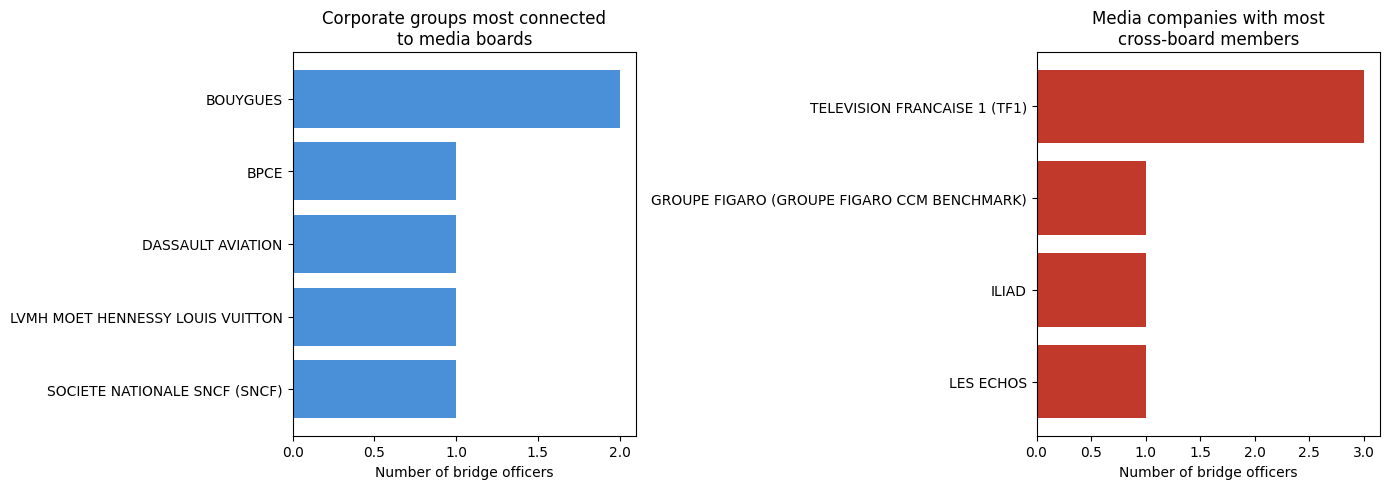

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: non-media companies by bridge-officer count
ax = axes[0]
top_corp = corp_media_exposure.head(10)
ax.barh(top_corp["company"], top_corp["nb_bridges"], color="#4A90D9")
ax.set_xlabel("Number of bridge officers")
ax.set_title("Corporate groups most connected\nto media boards")
ax.invert_yaxis()

# Right: media companies by bridge-officer count
ax = axes[1]
ax.barh(media_exposure["media_company"], media_exposure["nb_bridges"], color="#C0392B")
ax.set_xlabel("Number of bridge officers")
ax.set_title("Media companies with most\ncross-board members")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Network visualization — corporate-media board links

The graph below shows only bridge persons and the companies they connect.
- **Red boxes** = media companies
- **Blue boxes** = non-media (corporate) companies
- **Orange circles** = bridge persons, sized by total number of mandates
- Hover over any node for details; hover over an edge for the officer's role.

In [33]:
from pyvis.network import Network

# Build subgraph: bridge persons + their companies (both worlds)
G_media = nx.DiGraph()

for person_name in bridge_names:
    # Find the node ID in G for this person
    person_nodes = [nid for nid, d in G.nodes(data=True)
                    if d.get("type") == "Person" and d.get("displayName") == person_name]
    if not person_nodes:
        continue
    person_id = person_nodes[0]
    G_media.add_node(person_id, **G.nodes[person_id])

    for _, company_id, edge_attrs in G.out_edges(person_id, data=True):
        if edge_attrs.get("type") == "IS_OFFICER_OF":
            G_media.add_node(company_id, **G.nodes[company_id])
            G_media.add_edge(person_id, company_id, **edge_attrs)

print(f"Media influence subgraph: {G_media.number_of_nodes()} nodes, {G_media.number_of_edges()} edges")

# Person → mandate count for sizing
person_mandate_count = {
    nid: G_media.out_degree(nid)
    for nid, d in G_media.nodes(data=True) if d.get("type") == "Person"
}

net_media = Network(height="750px", width="100%", directed=True, notebook=True, cdn_resources="in_line")

for node_id, attrs in G_media.nodes(data=True):
    label = attrs.get("displayName", str(node_id))
    if attrs.get("type") == "Company":
        is_media_node = str(node_id) in MEDIA_SIRENS
        color = "#C0392B" if is_media_node else "#4A90D9"
        category = "Media" if is_media_node else "Corporate"
        net_media.add_node(str(node_id), label=label, color=color, size=22,
                           title=f"[{category}] {label}", shape="box")
    else:
        nb_m = person_mandate_count.get(node_id, 1)
        net_media.add_node(str(node_id), label=label, color="#E07B39",
                           size=10 + nb_m * 7,
                           title=f"Bridge officer: {label}\n{nb_m} mandates")

for src, tgt, attrs in G_media.edges(data=True):
    tgt_is_media = str(tgt) in MEDIA_SIRENS
    color = "#C0392B" if tgt_is_media else "#888888"
    net_media.add_edge(str(src), str(tgt), title=attrs.get("qualite", ""),
                       color=color, width=2 if tgt_is_media else 1)

media_path = "media_influence.html"  # f"{path_data}/media_influence.html"
net_media.save_graph(media_path)
print(f"Visualization saved to {media_path}")
net_media.show(media_path)

Media influence subgraph: 15 nodes, 12 edges
Visualization saved to media_influence.html
media_influence.html


## 10. Expression evaluation — Approximate age of officers

Since TuringDB v1.22, arithmetic expressions are supported directly in `RETURN` projections.
Here we compute the approximate age of each officer from their birth year.

In [29]:
# Approximate age of officers using expression evaluation in RETURN (TuringDB v1.22)
print("Approximate age of company officers (2025 - birth year):")
df_ages = client.query("""
    MATCH (p) WHERE p.type = 'Person' AND p.annee_de_naissance > 0
    RETURN p.displayName, p.annee_de_naissance, 2025 - p.annee_de_naissance
    LIMIT 20
""")
df_ages.columns = ["officer", "birth_year", "approx_age"]
display(df_ages)

Approximate age of company officers (2025 - birth year):


,officer,birth_year,approx_age
0,BRIGITTE JONON (DE SIO),1960,65
1,GILLES DENOYEL,1954,71
2,ANNE-MARIE DESCÔTES,1959,66
3,BRUNO EVEN,1968,57
4,AURELIE FRIONNET,1977,48
5,FABRICE GUYON,1974,51
6,GERALD LACOSTE,1976,49
7,STEPHANE CHEVET-DEHAIL,1975,50
8,VIRGINIE DE MOLLERAT DU JEU (CHAPRON),1961,64
9,SANDRINE LHENRY,1974,51


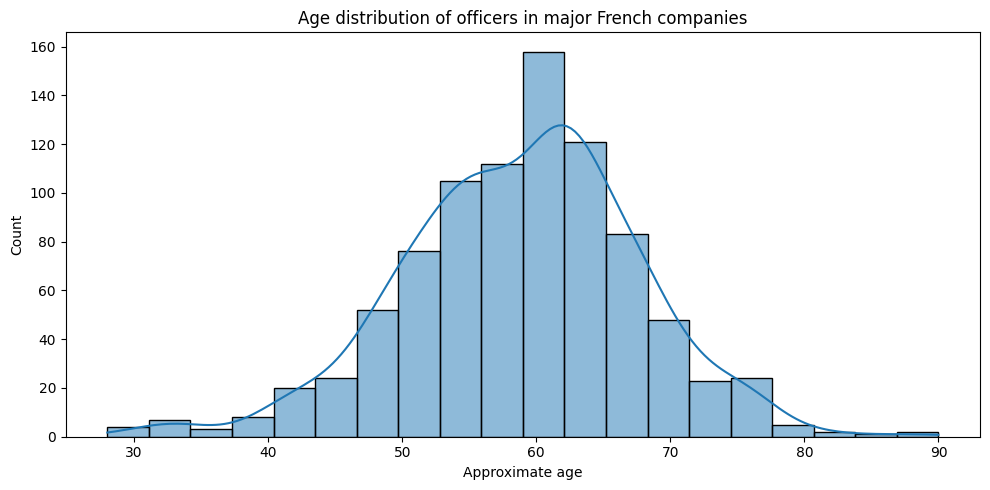

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of approximate ages
df_all_ages = client.query("""
    MATCH (p) WHERE p.type = 'Person' AND p.annee_de_naissance > 0
    RETURN 2025 - p.annee_de_naissance
""")
df_all_ages.columns = ["approx_age"]

plt.figure(figsize=(10, 5))
sns.histplot(df_all_ages["approx_age"], bins=20, kde=True)
plt.xlabel("Approximate age")
plt.ylabel("Count")
plt.title("Age distribution of officers in major French companies")
plt.tight_layout()
plt.show()

## 11. Visualization

In [32]:
from pyvis.network import Network

# Build a subgraph: only CEO-level officers (Directeur Général / Président)
key_roles = {"Directeur Général", "Président du conseil d'administration"}

G_sub = nx.DiGraph()
for src, tgt, attrs in G.edges(data=True):
    if attrs.get("qualite") in key_roles:
        G_sub.add_node(src, **G.nodes[src])
        G_sub.add_node(tgt, **G.nodes[tgt])
        G_sub.add_edge(src, tgt, **attrs)

print(f"Subgraph (key roles only): {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges")

net = Network(height="600px", width="100%", directed=True, notebook=True, cdn_resources="in_line")

for node_id, attrs in G_sub.nodes(data=True):
    label = attrs.get("displayName", str(node_id))
    if attrs.get("type") == "Company":
        net.add_node(str(node_id), label=label, color="#4A90D9", size=20, title=f"Company: {label}")
    else:
        net.add_node(str(node_id), label=label, color="#E07B39", size=12, title=f"Officer: {label}")

for src, tgt, attrs in G_sub.edges(data=True):
    net.add_edge(str(src), str(tgt), title=attrs.get("qualite", ""), color="#888888")

viz_path = "corporate_network.html"  # f"{path_data}/corporate_network.html"
net.save_graph(viz_path)
print(f"Visualization saved to {viz_path}")
net.show(viz_path)

Subgraph (key roles only): 92 nodes, 58 edges
Visualization saved to corporate_network.html
corporate_network.html


## 12. Natural language to Cypher (LLM)

We use an LLM to translate natural language questions into TuringDB Cypher queries.

In [ ]:
api_keys = {
    "OpenAI": os.getenv("OPENAI_API_KEY"),
    "Mistral": os.getenv("MISTRAL_API_KEY"),
    "Anthropic": os.getenv("ANTHROPIC_API_KEY"),
}

In [ ]:
turingdb_cypher_system_prompt = """\
You are a TuringDB graph database expert. TuringDB uses a subset of openCypher.
Generate ONLY valid TuringDB queries — never use unsupported clauses or functions.

## SUPPORTED SYNTAX

### Basic patterns
MATCH (n)                           -- all nodes
MATCH (n:Label)                     -- nodes with a specific label (only when labels are semantic)
MATCH (n {prop: 'value'})           -- inline property filter
MATCH (a)-[r:REL_TYPE]->(b)         -- directed relationship (only when rel types are semantic)
MATCH (a)-[r]->(b)                  -- directed relationship (generic)
MATCH (a)-[r]-(b)                   -- undirected relationship

### Return / filtering
RETURN n.property
RETURN n, r, m
RETURN n LIMIT 10
RETURN n SKIP 10 LIMIT 10
WHERE n.property = 'value'
WHERE n.property <> 'value'
WHERE n.property > 42  |  >= 42  |  < 42  |  <= 42
WHERE n.property IS NULL  |  IS NOT NULL
WHERE n.prop = 'a' AND m.prop = 'b'
WHERE n.prop = 'a' OR n.prop = 'b'

### Arithmetic expressions in RETURN
RETURN n.price * 1.1                -- multiply by constant
RETURN n.amount / 1000.0            -- divide by constant
RETURN n.value + n.tax              -- add two properties
RETURN 2025 - n.birth_year          -- compute age from birth year

### Aggregation
RETURN count(n)

### Schema introspection
CALL db.labels()
CALL db.edgeTypes()
CALL db.propertyTypes()

## STRICTLY FORBIDDEN (will cause errors)
- SKIP (standalone, without LIMIT)
- WITH
- RETURN *
- DISTINCT
- ORDER BY
- CREATE, MERGE, DELETE, SET, REMOVE
- UNION, subqueries: CALL { ... }
- Variable-length / multi-hop paths: [*2], [*1..3]
- Aggregation functions other than count(): sum(), avg(), min(), max()
- String functions: toLower(), toUpper(), contains(), startsWith(), endsWith(), trim()
- Math functions: abs(), round(), sqrt()
- List comprehensions, named paths
- Variable names `end` or `start` (reserved) — use `e`, `s`, or other aliases
- Double-quoted strings — always single quotes: WHERE n.name = 'Alice'

## SCHEMA CONTEXT
NODE LABELS
{node_labels}

RELATIONSHIP TYPES
{rel_types}

PROPERTIES
{properties}

SAMPLE DATA
{sample_data}

## INSTRUCTIONS
1. Follow the filtering guidance in the schema context exactly.
2. Use ONLY labels, relationship types, and property names listed above.
3. Always use single quotes for string literals.
4. Arithmetic expressions in RETURN are supported — use them when the question implies a calculation.
5. If the query cannot be expressed in supported syntax, say so explicitly instead of generating an invalid query.
6. Return ONLY the raw Cypher query — no markdown formatting, no code blocks, no backticks, no explanations before or after.
"""

In [ ]:
# Discover schema
_labels     = client.query("CALL db.labels()")
_edge_types = client.query("CALL db.edgeTypes()")
_props      = client.query("CALL db.propertyTypes()")

_label_vals   = _labels.iloc[:, 1].tolist()
_edgetype_vals = _edge_types.iloc[:, 1].tolist()
_prop_names   = _props.iloc[:, 1].tolist()

# Node labels section
if set(_label_vals) <= {"Node"}:
    _node_labels_text = "All nodes use the generic label 'Node'. DO NOT use MATCH (n:SomeLabel) syntax."
    if "type" in _prop_names:
        _type_vals = client.query("MATCH (n) WHERE n.type IS NOT NULL RETURN n.type LIMIT 50")
        #_type_vals = list(np.unique(_type_vals.values))
        _node_labels_text += f"\nFilter by semantic type using WHERE n.type = '<value>'. Available values: {np.unique(_type_vals.iloc[:, 0].tolist())}"
else:
    _node_labels_text = f"Use MATCH (n:Label) syntax. Available labels: {_label_vals}"

# Edge types section
if set(_edgetype_vals) <= {"CONNECTED"}:
    _rel_types_text = "All relationships use generic type 'CONNECTED'. DO NOT use -[:REL_TYPE]-> syntax."
    if "type" in _prop_names:
        _rtype_vals = client.query("MATCH ()-[r]->() WHERE r.type IS NOT NULL RETURN r.type LIMIT 50")
        #_rtype_vals = list(np.unique(_rtype_vals.values))
        _rel_types_text += f"\nFilter by semantic type using WHERE r.type = '<value>'. Available values: {np.unique(_rtype_vals.iloc[:, 0].tolist())}"
else:
    _rel_types_text = f"Use -[:TYPE]-> syntax. Available types: {_edgetype_vals}"

# Sample nodes
_sample_props = [p for p in ["type", "displayName", "qualite", "annee_de_naissance"] if p in _prop_names]
_sample_data = client.query(f"MATCH (n) RETURN {', '.join(f'n.{p}' for p in _sample_props)} LIMIT 5")

system_prompt = turingdb_cypher_system_prompt.replace("{node_labels}", _node_labels_text) \
                                              .replace("{rel_types}", _rel_types_text) \
                                              .replace("{properties}", _props.iloc[:, 1:].to_string(index=False)) \
                                              .replace("{sample_data}", _sample_data.to_string(index=False))
print("System prompt ready")

In [ ]:
%%time

provider = "Anthropic"
question = "Which companies have officers born before 1960?"

cypher_query = natural_language_to_cypher(
    question=question,
    system_prompt=system_prompt,
    provider=provider,
    model="claude-haiku-4-5-20251001",
    api_key=api_keys[provider],
)
print(f"Question: {question}")
print(f"Generated query:\n{cypher_query}")

In [ ]:
%%time

result = client.query(cypher_query)
display(result)

In [ ]:
%%time

provider = "Anthropic"
question = "How many officers does each company have?"

cypher_query = natural_language_to_cypher(
    question=question,
    system_prompt=system_prompt,
    provider=provider,
    model="claude-haiku-4-5-20251001",
    api_key=api_keys[provider],
)
print(f"Question: {question}")
print(f"Generated query:\n{cypher_query}")
try:
    display(client.query(cypher_query))
except turingdb.exceptions.TuringDBException as e:
    print(f"\nTuringDBException: {e}\n")